In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from matplotlib.pyplot import Patch

In [ ]:
import geopandas as gpd
radios = gpd.read_file("radios-censales-2022.geojson")

In [43]:
print(radios.shape)
print(radios.columns.tolist())

(66502, 8)
['codigo', 'cod_prov', 'cod_dep', 'fraccion', 'radio', 'POB_TOT_P', 'VIV_TOT_P', 'geometry']


In [ ]:
#Valido que el codigo identificador esté construido de la manera en que parece estar construido, concatenando prov, dep, frac, radio

columnas_codigo = ["codigo","cod_prov","cod_dep","fraccion","radio"]

for columna in columnas_codigo:radios[columna] = (radios[columna].astype("string").str.strip()) #Todo a string y sin espacios

# Completo ceros a la izquierda según la estructura observada

radios["codigo"] = radios["codigo"].str.zfill(9)
radios["cod_prov"] = radios["cod_prov"].str.zfill(2)
radios["cod_dep"] = radios["cod_dep"].str.zfill(3)
radios["fraccion"] = radios["fraccion"].str.zfill(2)
radios["radio"] = radios["radio"].str.zfill(2)
radios["codigo_reconstruido"] = ( radios["cod_prov"] + radios["cod_dep"] + radios["fraccion"] + radios["radio"])

comparacion_codigo = (radios["codigo"] == radios["codigo_reconstruido"])
print("Códigos que coinciden:",comparacion_codigo.sum())
print("Códigos que no coinciden:",(~comparacion_codigo).sum())
print("Proporción coincidente:",comparacion_codigo.mean())

Códigos que coinciden: 66502
Códigos que no coinciden: 0
Proporción coincidente: 1.0


In [45]:
PARTIDOS_SELECCIONADOS ={
 "035":"Avellaneda",
 "371":"General San Martín",
 "427":"La Matanza",
 "434":"Lanús",
 "490":"Lomas de Zamora",
 "840":"Tres de Febrero",
 "861":"Vicente López",
 "756":"San Isidro",
 "568":"Morón"
}

In [ ]:
condicion_caba = (radios["cod_prov"] == "02") #CABA
condicion_partidos = (radios["cod_prov"] == "06") & (radios["cod_dep"].isin(PARTIDOS_SELECCIONADOS.keys())) #AMBA, los partidos mencionados arriba
exclusion_la_matanza_periferico = (radios["cod_dep"] == "427") & (radios["fraccion"].astype(int) > 80 ) #Saco de La Matanza partidos como Virrey del Pino, Gonzalez Catan y 20 de Junio porque están muy lejos de CABA.

radios_estudio = radios.loc[condicion_caba | (condicion_partidos & (~exclusion_la_matanza_periferico)) ].copy()
radios_estudio = radios_estudio.reset_index(drop=True)
radios_estudio["prov_dep"] = radios_estudio["cod_prov"] + radios_estudio["cod_dep"]

print("Cantidad total de nodos en el area de estudio:",len(radios_estudio))
print("Cantidad de códigos únicos:",radios_estudio["codigo"].nunique())
print((radios_estudio["prov_dep"].value_counts().sort_index())) #La Matanza y CABA ganan en cantidad de partidos
print("Cantidad de departamentos/comunas:",(radios_estudio["prov_dep"]).nunique()) #las 15 comunas caba + 9 deptos amba elegidos, 24 en total deberian ser
print("CRS:", radios_estudio.crs)

Cantidad total de nodos en el area de estudio: 8847
Cantidad de códigos únicos: 8847
prov_dep
02007     352
02014     202
02021     256
02028     294
02035     225
02042     230
02049     266
02056     202
02063     192
02070     200
02077     236
02084     267
02091     330
02098     322
02105     246
06035     429
06371     524
06427    1250
06434     552
06490     705
06568     412
06756     360
06840     432
06861     363
Name: count, dtype: Int64
Cantidad de departamentos/comunas: 24
CRS: EPSG:4326


cod_prov
02    3820
06    5027
Name: count, dtype: int64


,jurisdiccion,area_nombre,cantidad_radios
0,CABA,CABA,3820
1,Provincia de Buenos Aires,Avellaneda,429
2,Provincia de Buenos Aires,General San Martín,524
3,Provincia de Buenos Aires,La Matanza,1250
4,Provincia de Buenos Aires,Lanús,552
5,Provincia de Buenos Aires,Lomas de Zamora,705
6,Provincia de Buenos Aires,Morón,412
7,Provincia de Buenos Aires,San Isidro,360
8,Provincia de Buenos Aires,Tres de Febrero,432
9,Provincia de Buenos Aires,Vicente López,363


,area_nombre,cantidad_radios,poblacion_total,viviendas_totales
0,Avellaneda,429,366117,145330
1,CABA,3820,3095454,1614354
2,General San Martín,524,444503,173636
3,La Matanza,1250,1343430,457429
4,Lanús,552,460081,181026
5,Lomas de Zamora,705,685644,245682
6,Morón,412,329517,141238
7,San Isidro,360,295978,121287
8,Tres de Febrero,432,362319,149364
9,Vicente López,363,280541,125737


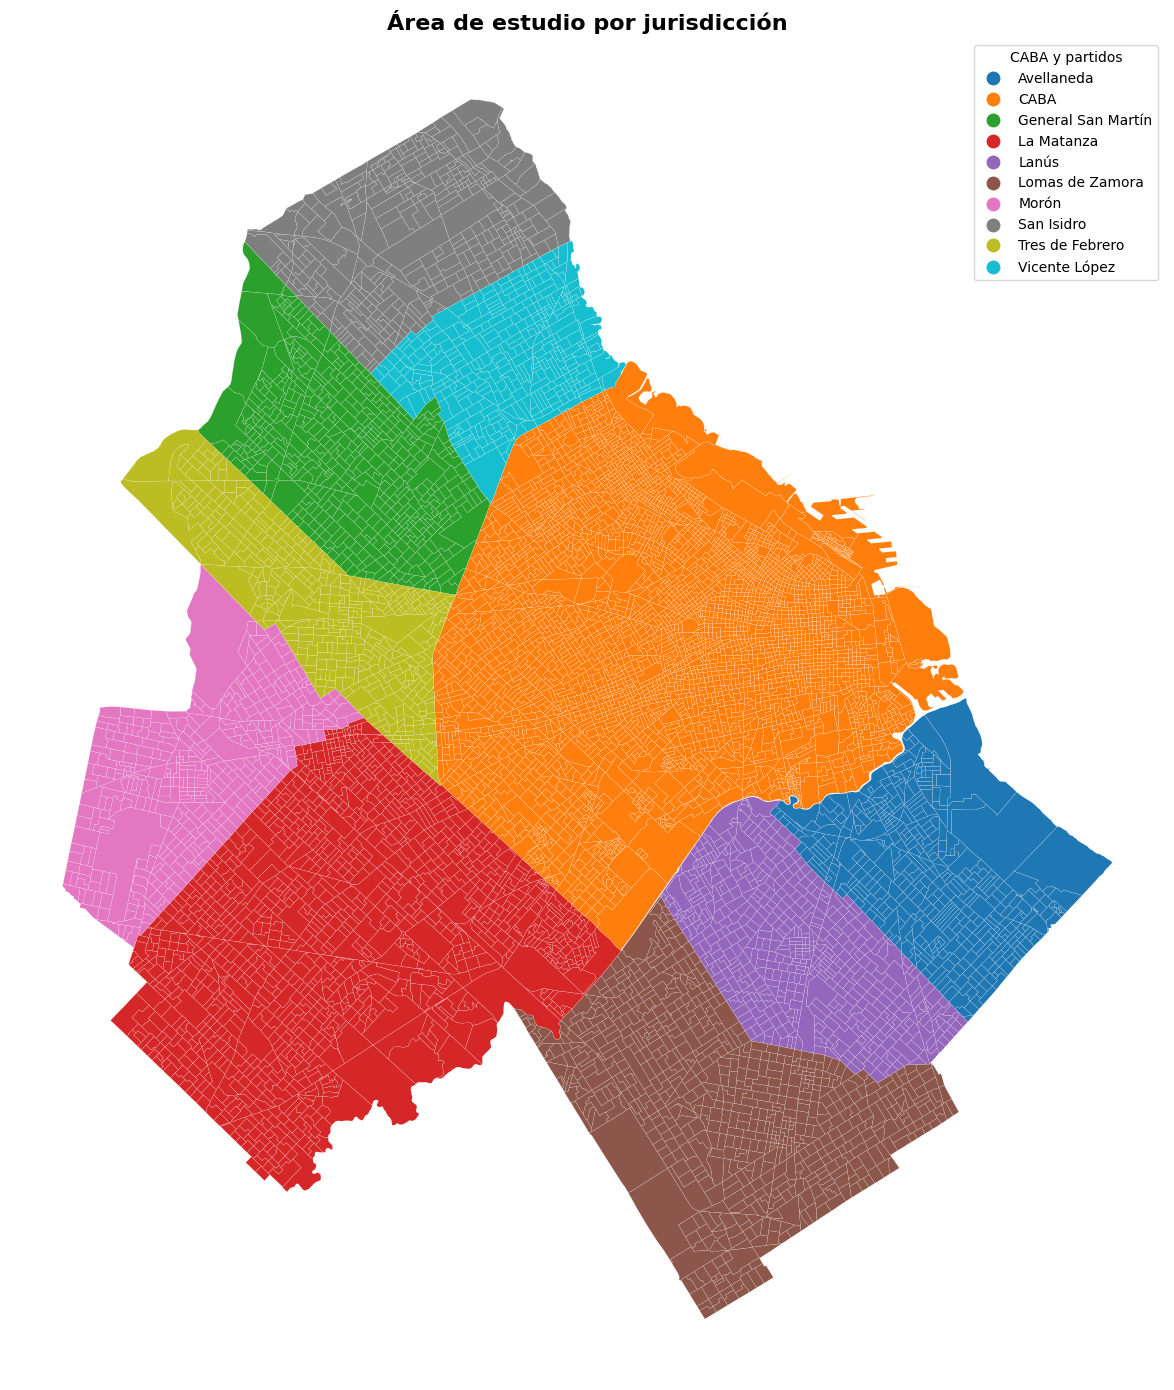

In [ ]:
radios_estudio["jurisdiccion"] = np.where(radios_estudio["cod_prov"] == "02","CABA","Provincia de Buenos Aires")
radios_estudio["area_nombre"] = np.where(radios_estudio["cod_prov"] == "02","CABA",radios_estudio["cod_dep"].map(PARTIDOS_SELECCIONADOS))

print(radios_estudio["cod_prov"].value_counts().sort_index()) #radios en CABA vs. AMBA

conteo_por_area = (radios_estudio.groupby(["jurisdiccion","area_nombre"]).size().reset_index(name="cantidad_radios").sort_values(["jurisdiccion","area_nombre"]))
display(conteo_por_area)

areas_obtenidas = set(radios_estudio["area_nombre"].dropna().unique())
resumen_areas = (radios_estudio.groupby("area_nombre").agg(cantidad_radios=("codigo","size"),poblacion_total=("POB_TOT_P","sum"),viviendas_totales=("VIV_TOT_P","sum")).reset_index().sort_values("area_nombre"))
display(resumen_areas) #Resumen por área

fig, ax = plt.subplots(figsize=(14, 14))
radios_estudio.plot(
    ax=ax,
    column="area_nombre",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.10,
    cmap="tab10"
)

ax.set_title("Área de estudio por jurisdicción",fontsize=16,fontweight="bold")
ax.set_axis_off()
leyenda = ax.get_legend()
leyenda.set_title("CABA y partidos")
plt.tight_layout()
plt.show()

In [ ]:
radios_red = radios_estudio[["codigo","area_nombre","POB_TOT_P","VIV_TOT_P","geometry"]].copy()
radios_red = radios_red.reset_index(drop=True)
print("Radios para construir la red:", len(radios_red))

pares_candidatos = gpd.sjoin(radios_red[["codigo","geometry"]],radios_red[["codigo","geometry"]],how="inner",predicate="intersects",lsuffix="a",rsuffix="b") #Se joinean los radios entre sí
print(pares_candidatos.columns.tolist())
display(pares_candidatos.head())

pares_candidatos = pares_candidatos.loc[pares_candidatos["codigo_a"] != pares_candidatos["codigo_b"]].copy() #un radio A es vecino del mismo A, pero ese par no me sirve

Radios para construir la red: 8847
['codigo_a', 'geometry', 'index_b', 'codigo_b']


,codigo_a,geometry,index_b,codigo_b
0,060350203,"POLYGON ((-58.29917 -34.66794, -58.29915 -34.6...",96,060350205
0,060350203,"POLYGON ((-58.29917 -34.66794, -58.29915 -34.6...",87,060350302
0,060350203,"POLYGON ((-58.29917 -34.66794, -58.29915 -34.6...",89,060350204
0,060350203,"POLYGON ((-58.29917 -34.66794, -58.29915 -34.6...",3,060350202
0,060350203,"POLYGON ((-58.29917 -34.66794, -58.29915 -34.6...",0,060350203


In [ ]:
pares_candidatos["radio_a"] = (pares_candidatos[["codigo_a", "codigo_b"]].min(axis=1))
pares_candidatos["radio_b"] = (pares_candidatos[["codigo_a", "codigo_b"]].max(axis=1)) #Esta linea y la anterior ordenan los radios adyacentes en la forma (radio de menor ID, radio de mayor ID)
pares_candidatos = (pares_candidatos[["radio_a","radio_b"]].drop_duplicates().reset_index(drop=True)) #Una sola observacion por par de radios.
print("Pares candidatos:",len(pares_candidatos))

geometria_por_radio = (radios_red.set_index("codigo").geometry.to_dict()) #Crea un diccionario de la forma { "radio":"geometria"}, por ejemplo {"020010101":"POLYGON(...)","020010102":"POLYGON(...)"} 

#Cual es la longitud del contorno/borde  del poligono de cada radio, que es compartido dado un par de radios censales? 
def longitud_frontera_compartida(fila):

    geometria_a = geometria_por_radio[fila["radio_a"]]
    geometria_b = geometria_por_radio[fila["radio_b"]]
    frontera_compartida = (geometria_a.boundary.intersection(geometria_b.boundary))

    return frontera_compartida.length

pares_candidatos["longitud_frontera"] = pares_candidatos.apply(longitud_frontera_compartida,axis=1)
aristas = pares_candidatos.loc[pares_candidatos["longitud_frontera"] > 0].copy() #Solo me quedo con los pares de radios que comparten una frontera con longitud positiva

Pares candidatos: 29183


Cantidad de aristas Rook: 23348


,radio_a,radio_b,longitud_frontera
0,060350203,060350205,0.010608
1,060350203,060350302,0.001334
2,060350203,060350204,0.005578
3,060350202,060350203,0.013440
4,060350201,060350203,0.020993


Nodos: 8847
Aristas: 23348
¿La red es conexa?: True
Cantidad de componentes: 1
count    8847.000000
mean        5.278173
std         1.560536
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        30.000000
Name: grado, dtype: float64
Cantidad de radios aislados: 0
Primeros aislados: []
Tamaños de las diez componentes principales: [8847]


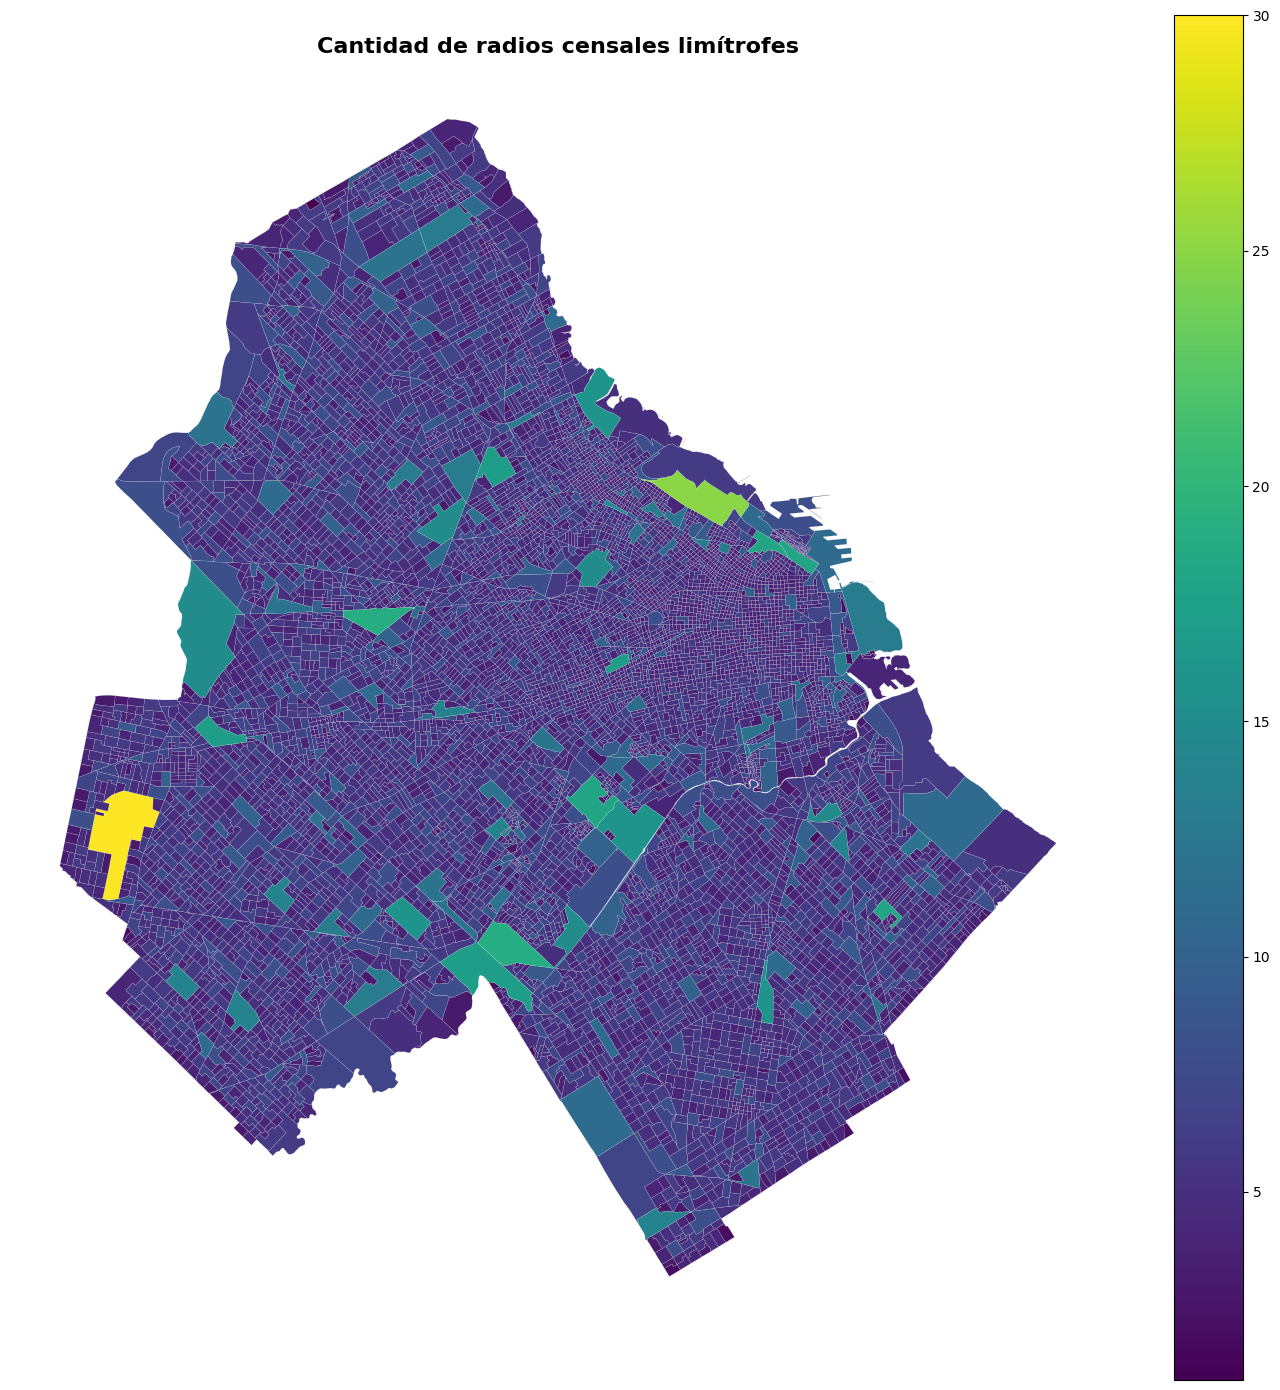

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
aristas = aristas.reset_index(drop=True)
print("Cantidad de aristas Rook:", len(aristas)) #Aristas Rook son aristas que representan radios que comparten una longitud de frontera (por el contrario, aristas conectadas por un vertice solamente no se consideran)
display(aristas.head())

G_estudio = nx.Graph() #Armo la red
G_estudio.add_nodes_from(radios_red["codigo"]) #Agrego los radios
G_estudio.add_edges_from(aristas[["radio_a","radio_b"]].itertuples(index=False,name=None)) #Agrego las aristas

print("Nodos:",G_estudio.number_of_nodes())
print("Aristas:",G_estudio.number_of_edges())
print("¿La red es conexa?:",nx.is_connected(G_estudio))
print("Cantidad de componentes:",nx.number_connected_components(G_estudio)) #Genial, 1 sola componente conexa

grados = pd.Series(dict(G_estudio.degree()),name="grado") #G_estudio.degree() devuelve [(radio,grado_radio)] para todo radio, es un objeto llamado DegreeView, que dict() convierte en diccionario  {'radio':'grado'}. 
                                                            #pd.Series me devuelve esta info en formato tabular.
print(grados.describe()) 

radios_aislados = list(nx.isolates(G_estudio)) #No debiera haber ninguno ya que hay una sola componente conexa,  pero chequeo por las dudas
print("Cantidad de radios aislados:",len(radios_aislados)) 
print("Primeros aislados:",radios_aislados[:20]) #No tengo ninguno!

radios_red["grado"] = (radios_red["codigo"].map(dict(G_estudio.degree()))) #Creo una columna con el grado de cada radio usando el dict que tenía

fig, ax = plt.subplots(figsize=(14, 14))

radios_red.plot(
    ax=ax,
    column="grado",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.08
)

ax.set_title("Cantidad de radios censales limítrofes",fontsize=16,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
#Exporto nodos y aristas

nodos_exportar = radios_red[["codigo","area_nombre","POB_TOT_P","VIV_TOT_P","grado","componente"]].copy()
nodos_exportar.to_csv("nodos_radios_estudio.csv",index=False)
aristas_exportar = aristas[["radio_a","radio_b","longitud_frontera"]].copy()
aristas_exportar.to_csv("aristas_radios_estudio.csv",index=False)

from google.colab import files #Todo este notebook (GeopandasCode.ipynb) lo creé y ejecuté desde la notebook de mi hermano, me descargo los archivos de info de nodos y aristas, y vuelvo a mi computadora laboral a seguir.

files.download("nodos_radios_estudio.csv")
files.download("aristas_radios_estudio.csv")

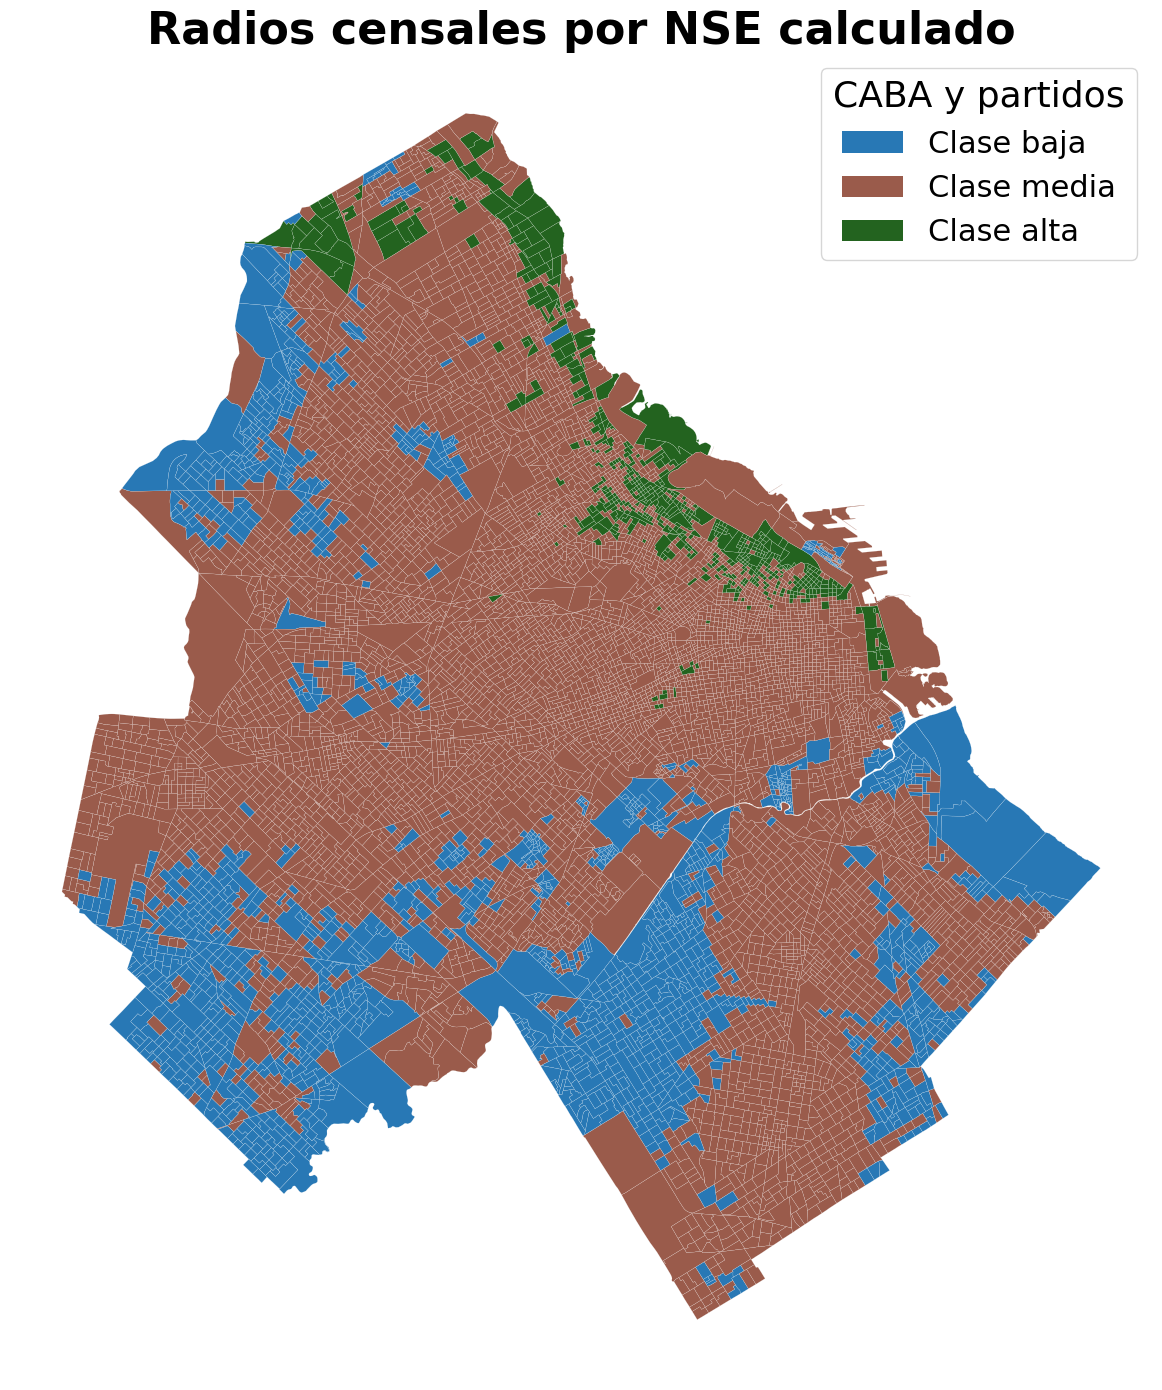

In [1]:
#Muestro la imagen guardada de este grafico
from IPython.display import Image, display

display(Image(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\RadiosCensalesNSE.png"))